<a href="https://colab.research.google.com/github/balamuruganganesan77-coder/OasisInfobyte_DataAnalytics/blob/main/Task3_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
Dataset Name: /content/student_data.csv

========== FIRST 5 ROWS ==========
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 ro

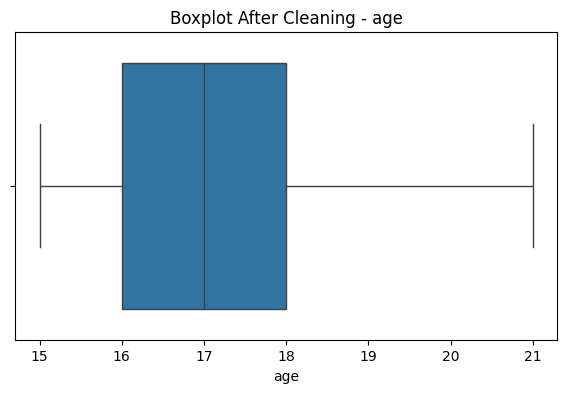

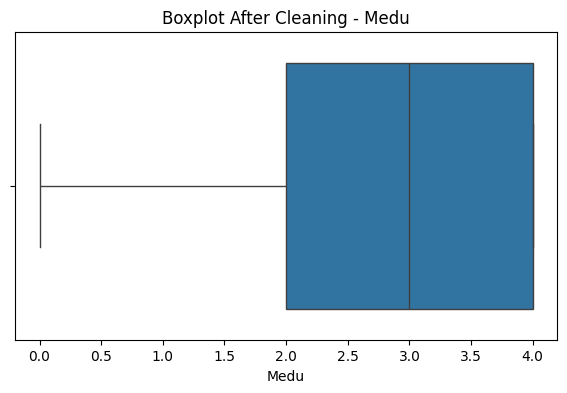

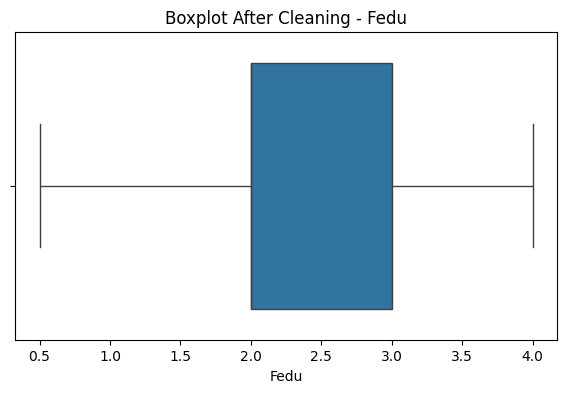

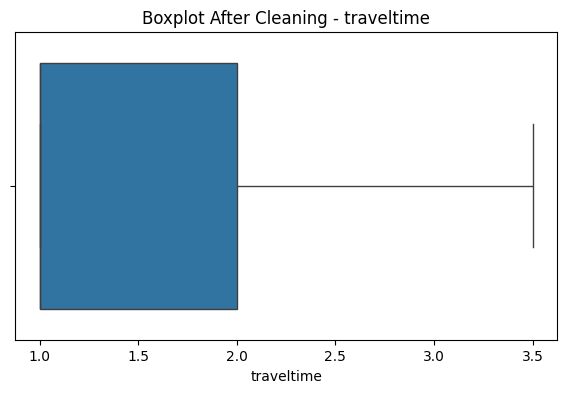

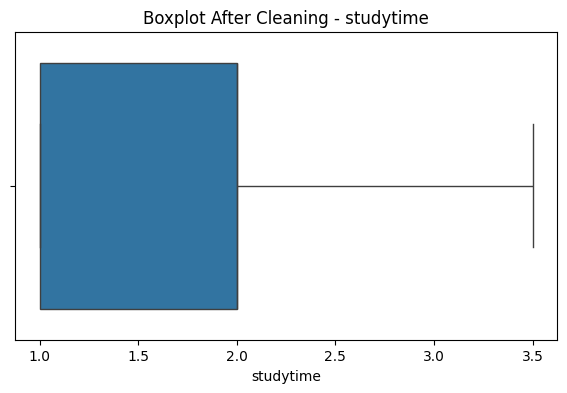

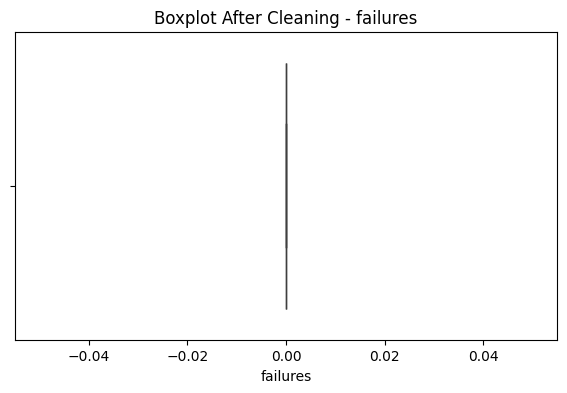

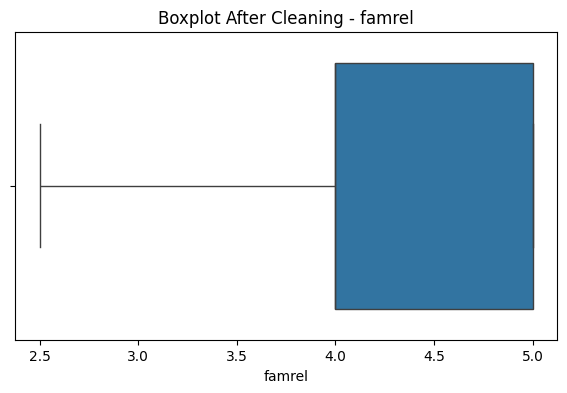

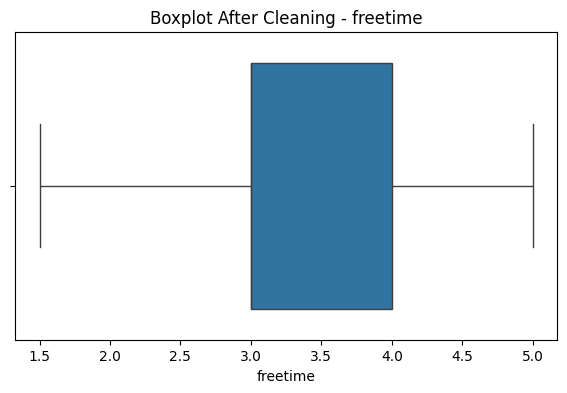

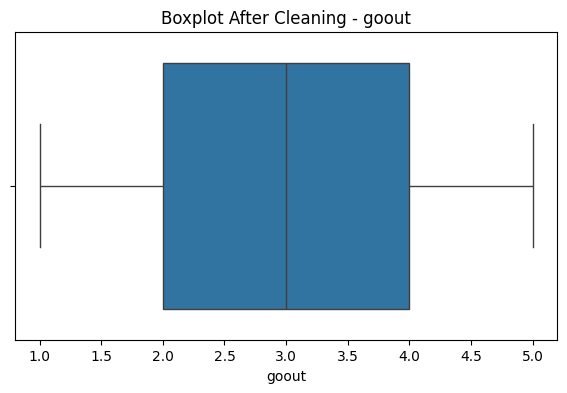

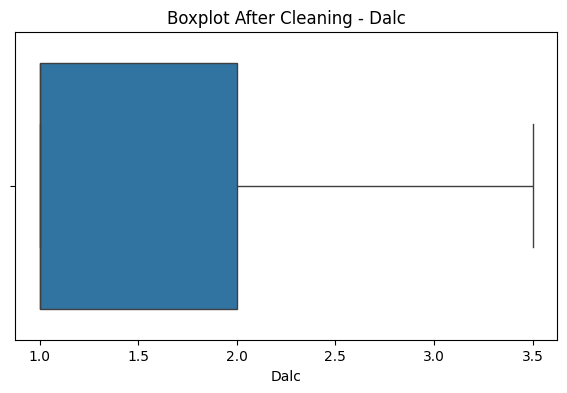

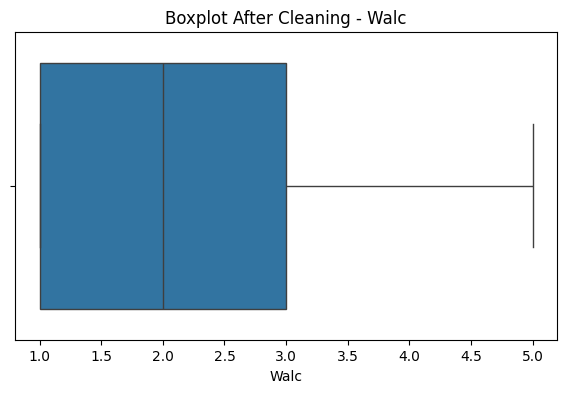

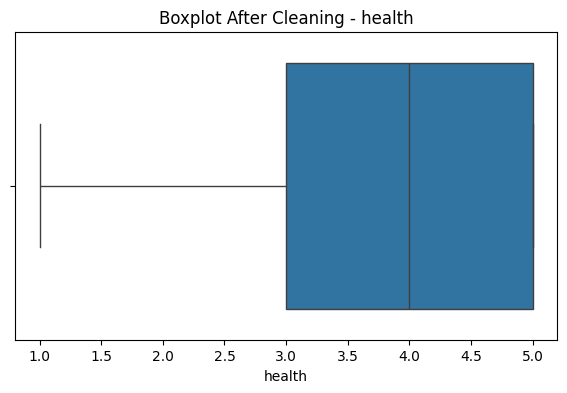

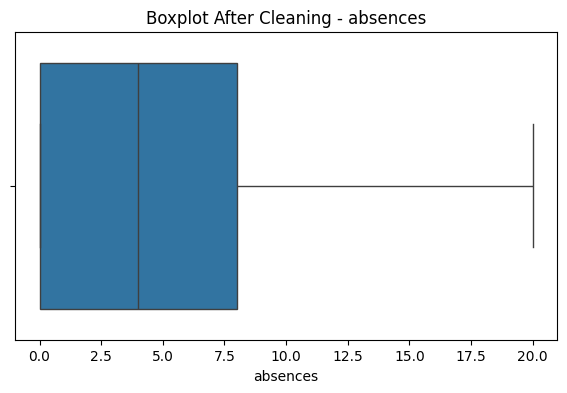

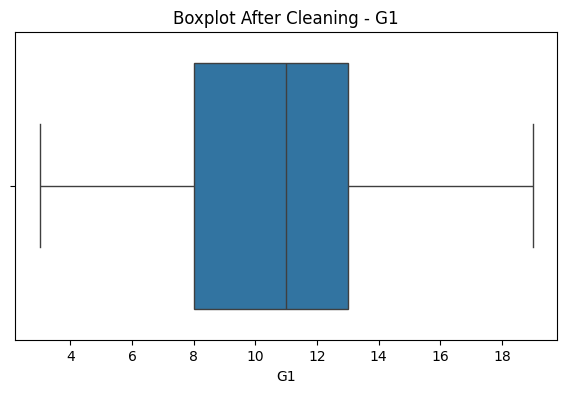

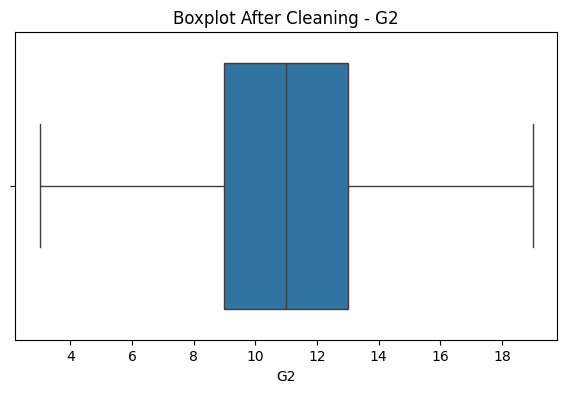

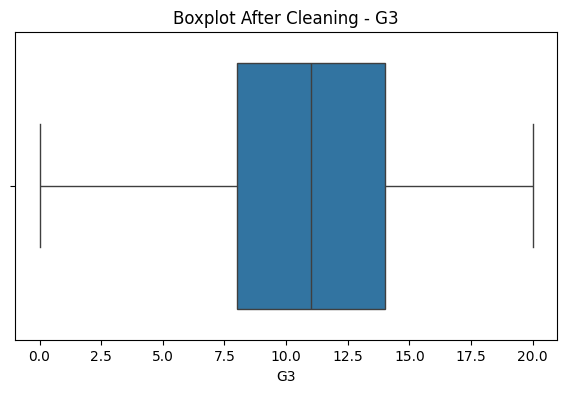


========== CLEANED DATASET ==========
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4   4.0  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1   1.0  at_home     other  ...   
2     GP   F   15       U     LE3       T     1   1.0  at_home     other  ...   
3     GP   F   15       U     GT3       T     4   2.0   health  services  ...   
4     GP   F   16       U     GT3       T     3   3.0    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0    4.0      3.0      4   1.0     1      3        6   5   6   6  
1    5.0      3.0      3   1.0     1      3        4   5   5   6  
2    4.0      3.0      2   2.0     3      3       10   7   8  10  
3    3.0      2.0      2   1.0     1      5        2  15  14  15  
4    4.0      3.0      2   1.0     2      5        4   6  10  10  

[5 rows x 33 columns]

Cleaned dataset saved successfully!
File: cleane

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_name = '/content/student_data.csv'
df = pd.read_csv(file_name)

print("Dataset Loaded Successfully!")
print("Dataset Name:", file_name)

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe(include="all"))

rows_before = df.shape[0]
columns_before = df.shape[1]
missing_before = df.isnull().sum().sum()
duplicates_before = df.duplicated().sum()

print("\n========== HANDLING MISSING VALUES ==========")

for column in df.columns:

    if df[column].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[column]):
            df[column] = df[column].fillna(df[column].median())
            print(column, "-> Missing values filled using Median")

        else:
            df[column] = df[column].fillna(df[column].mode()[0])
            print(column, "-> Missing values filled using Mode")

print("\n========== REMOVING DUPLICATES ==========")

df.drop_duplicates(inplace=True)

print("Duplicates before:", duplicates_before)
print("Duplicates after:", df.duplicated().sum())

print("\n========== STANDARDIZATION ==========")

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

print("Text columns standardized successfully.")

print("\n========== DATA TYPES AFTER CLEANING ==========")

print(df.dtypes)

print("\n========== OUTLIER DETECTION ==========")

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Outliers:", outliers)

    df[column] = df[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("\n========== AFTER CLEANING ==========")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Shape:")
print(df.shape)

rows_after = df.shape[0]
columns_after = df.shape[1]
missing_after = df.isnull().sum().sum()
duplicates_after = df.duplicated().sum()

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        rows_before,
        columns_before,
        missing_before,
        duplicates_before
    ],
    "After Cleaning": [
        rows_after,
        columns_after,
        missing_after,
        duplicates_after
    ]
})

print("\n========== BEFORE VS AFTER SUMMARY ==========")
print(summary.to_string(index=False))

print("\n========== OUTLIER VISUALIZATION ==========")

for column in numeric_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[column])

    plt.title("Boxplot After Cleaning - " + column)
    plt.xlabel(column)

    plt.show()

print("\n========== CLEANED DATASET ==========")

print(df.head())

output_file = "cleaned_student_data.csv"

df.to_csv(output_file, index=False)

print("\nCleaned dataset saved successfully!")
print("File:", output_file)

print("\n================================================")
print("TASK 3 COMPLETED SUCCESSFULLY! ✅")
print("================================================")